# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 15:17:23,599] A new study created in memory with name: no-name-c50c419a-a053-44db-89b6-f7cb4876ad97
[I 2026-04-09 15:17:23,898] Trial 0 finished with value: 0.7384615384615385 and parameters: {'n_estimators': 219, 'max_depth': 11}. Best is trial 0 with value: 0.7384615384615385.
[I 2026-04-09 15:17:24,073] Trial 1 finished with value: 0.7058823529411765 and parameters: {'n_estimators': 150, 'max_depth': 6}. Best is trial 0 with value: 0.7384615384615385.
[I 2026-04-09 15:17:24,291] Trial 2 finished with value: 0.7049180327868853 and parameters: {'n_estimators': 182, 'max_depth': 7}. Best is trial 0 with value: 0.7384615384615385.
[I 2026-04-09 15:17:24,415] Trial 3 finished with value: 0.7049180327868853 and parameters: {'n_estimators': 108, 'max_depth': 5}. Best is trial 0 with value: 0.7384615384615385.
[I 2026-04-09 15:17:24,657] Trial 4 finished with value: 0.7096774193548387 and parameters: {'n_estimators': 207, 'max_depth': 7}. Best is trial 0 with value: 0.73846153

RF F1: 0.7575757575757576
LR F1: 0.71875
SVM F1: 0.75
KNN F1: 0.7536231884057971


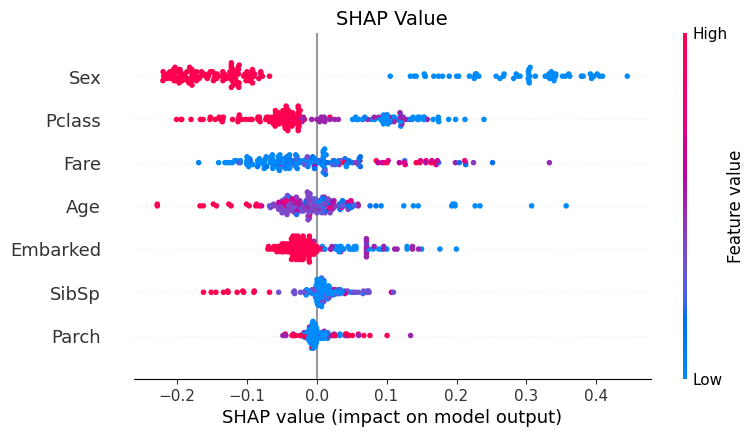

Stacking F1: 0.7619047619047619


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

전체 코드 답안 작성 ▼

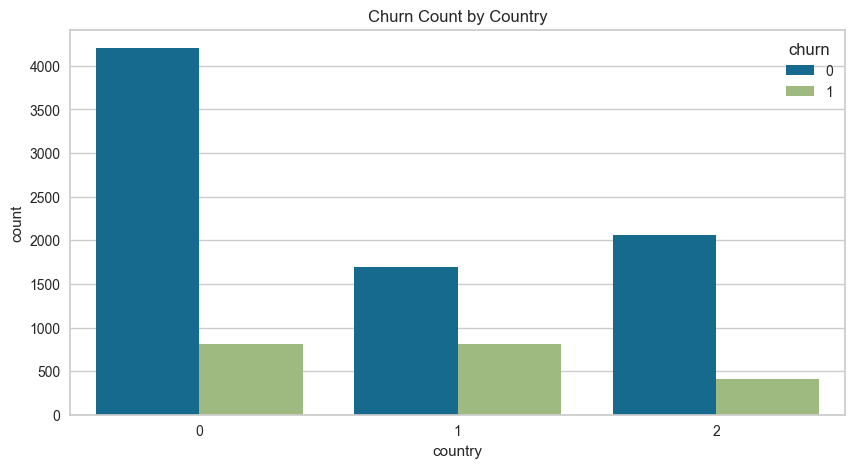

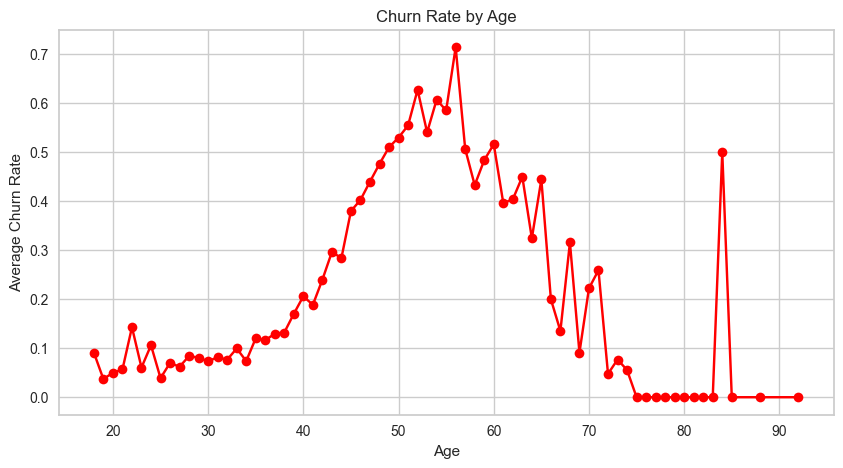

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0390
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.0800
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.0940
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,1.0170
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1020
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0240
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.0690
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0090
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0090
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0100


[I 2026-04-09 16:44:45,869] A new study created in memory with name: no-name-dce0b624-5b21-4fbf-afa8-c5ad957445a4
[I 2026-04-09 16:44:47,294] Trial 0 finished with value: 0.5929339477726574 and parameters: {'iterations': 262, 'depth': 8, 'learning_rate': 0.035807700858961344}. Best is trial 0 with value: 0.5929339477726574.
[I 2026-04-09 16:44:49,768] Trial 1 finished with value: 0.6130952380952381 and parameters: {'iterations': 188, 'depth': 10, 'learning_rate': 0.08602862067539084}. Best is trial 1 with value: 0.6130952380952381.
[I 2026-04-09 16:44:50,168] Trial 2 finished with value: 0.5960061443932412 and parameters: {'iterations': 130, 'depth': 7, 'learning_rate': 0.05598179738938819}. Best is trial 1 with value: 0.6130952380952381.
[I 2026-04-09 16:44:50,369] Trial 3 finished with value: 0.5871271585557299 and parameters: {'iterations': 131, 'depth': 4, 'learning_rate': 0.06276978781476658}. Best is trial 1 with value: 0.6130952380952381.
[I 2026-04-09 16:44:51,087] Trial 4 fini

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


[I 2026-04-09 16:44:57,285] Trial 1 finished with value: 0.5678233438485805 and parameters: {'n_estimators': 121, 'max_depth': 3, 'learning_rate': 0.05785912202653563}. Best is trial 0 with value: 0.5748865355521936.


...

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


[I 2026-04-09 16:44:58,395] Trial 8 finished with value: 0.5770392749244713 and parameters: {'n_estimators': 257, 'max_depth': 14, 'learning_rate': 0.04822654149644085}. Best is trial 4 with value: 0.5941807044410413.
[I 2026-04-09 16:44:58,604] Trial 9 finished with value: 0.5735294117647058 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.09968172517601694}. Best is trial 4 with value: 0.5941807044410413.


[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-04-09 16:44:58,604] A new study created in memory with name: no-name-edfe0d6d-d288-4909-a600-40f17b75c22c
[I 2026-04-09 16:45:03,263] Trial 0 finished with value: 0.5692995529061102 and parameters: {'n_estimators': 134, 'max_depth': 10, 'learning_rate': 0.04263990887712418}. Best is trial 0 with value: 0.5692995529061102.
[I 2026-04-09 16:45:11,793] Trial 1 finished with value: 0.5684210526315789 and parameters: {'n_estimators': 251, 'max_depth': 10, 'learning_rate': 0.0142647808534096}. Best is trial 0 with value: 0.5692995529061102.
[I 2026-04-09 16:45:14,059] Trial 2 finished with value: 0.5780525502318392 and parameters: {'n_estimators': 168, 'max_depth': 5, 'learning_rate': 0.03823784057510328}. Best is trial 2 with value: 0.5780525502318392.
[I 2026-04-09 16:45:16,475] Trial 3 finished with value: 0.5931445603576752 and parameters: {'n_estimators': 221, 'max_depth': 4, 'learning_rate': 0.08844195534140316}. Best is trial 3 with value: 0.5931445603576752.
[I 2026-04-09 16:

CatBoost F1-Score: 0.6131
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

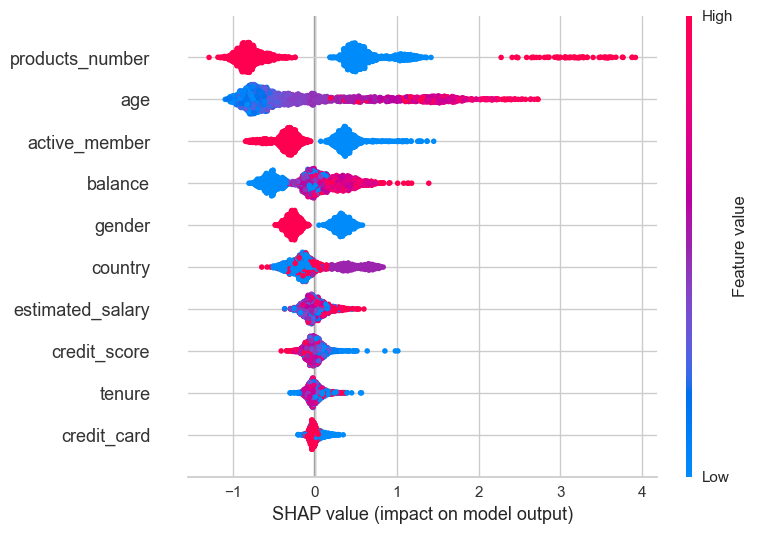

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
# 고유 식별자인 customer_id는 데이터 간의 독립성을 보장하지만 모델 학습 시 불필요하여 제거함. 
# 또한, country와 gender과 같은 범주형 데이터는 연산이 가능한 수치형으로 변환하기 위해 Label Encoding을 적용하여 모델이 패턴을 학습할 수 있도록 구성함.
df = df.drop(columns=['customer_id'], errors='ignore')
# 결측치 확인 결과 이상이 없음을 확인 하였으며, 범주형 변수의 수치화만으로도 충분한 변별력 확보가 가능하다고 판단함.
# 라벨 인코더 선언
le = LabelEncoder()

# 거주 국가를 수치형으로 변환함
df['country'] = le.fit_transform(df['country'])
# 성별을 수치형으로 변환함
df['gender'] = le.fit_transform(df['gender'])

# EDA 제안 - 시각화 및 해석
# plt 사용을 위한 matplotlib.pyplot 불러오기
import matplotlib.pyplot as plt
# sns 사용을 위한 seaborn 불러오기
import seaborn as sns
# 바그래프로 국가별 이탈자 수 확인
plt.figure(figsize=(10, 5)) # 그래프 크기를 설정
sns.countplot(data=df, x='country', hue='churn') # 국가별로 이탈 여부의 빈도를 막대로 나타냄
plt.title('Churn Count by Country') # 그래프의 제목 설정
plt.show()
# 그래프 해석: 특정 국가에서 타 국가 대비 이탈자의 절대적 수와 비율이 높게 나타남. 
# 이는 해당 지역의 금융 환경이나 경쟁사 마케팅 등 외부 요인이 이탈에 영향을 줄 수 있음을 나타냄.

# 꺾은선 그래프로 나이대별 평균 이탈률 변화 확인
# 나이별로 이탈의 평균값을 계산하여 추세 확인
age_churn_rate = df.groupby('age')['churn'].mean() # 나이별 이탈률 평균 계산
plt.figure(figsize=(10, 5)) # 그래프 크기 설정
plt.plot(age_churn_rate.index, age_churn_rate.values, marker='o', color='red') # 나이에 따른 이탈률을 선으로 그림
plt.title('Churn Rate by Age') # 그래프 제목 설정
plt.xlabel('Age') # X축 레이블을 나이로 설정
plt.ylabel('Average Churn Rate') # Y축 레이블을 평균 이탈률로 설정합니다.
plt.grid(True) # 눈금선 표시
plt.show()
# 그래프 해석: 나이가 증가함에 따라 이탈률이 점진적으로 상승하다가 50~60대 구간에서 최고를 기록함. 
# 이는 고령층 고객을 위한 자산 관리 서비스나 유지 보상 프로그램의 부재가 이탈의 주요 원인일 수도 있다는 인사이트를 제공.


# split
# 검증의 신뢰도를 높이기 위해 데이터를 8:2로 분할하며, 타겟 컬럼의 불균형을 고려하여 분할 시 비율을 유지함.
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

from pycaret.classification import *


# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# Feature Selection과 ML선정 기준
# PyCaret의 Feature Importance 기능을 참고하여 이탈과 상관관계가 낮은 변수가 있는지 검토함.
# 모든 변수가 일정 수준 이상의 중요도를 가져 전량 학습에 활용함.

# 다시 학습/검증 데이터를 feature X와 정답y로 나눔.
X_train = train_df.drop('churn', axis=1) 
y_train = train_df['churn']
X_valid = valid_df.drop('churn', axis=1)
y_valid = valid_df['churn']

# 스케일링 (변수들의 단위가 다르면 모델이 편향될 수 있으므로 표준화합니다)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 학습 데이터 기준으로 스케일러 학습 및 변환
X_valid_scaled = scaler.transform(X_valid)      # 검증 데이터는 학습 데이터의 기준을 적용하여 변환


# PyCaret을 통해 전수 모델을 비교한 결과, CatBoost, LightGBM, GBC, XGBoost가 상위 F1-Score를 기록함. 
# 단순 정확도(Accuracy)보다 F1-Score를 기준으로 삼은 이유는 이탈 고객을 정확히 찾아내는 것이 비즈니스 손실을 줄이는 데 훨씬 중요하기 때문.
# 따라서 성능이 검증된 상위 4개 부스팅 모델을 최종 후보로 선정함.

import optuna
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# [Optuna 목적 함수 정의] 각 모델별로 최적의 하이퍼파라미터를 찾습니다.
# 하이퍼파라미터 탐색 범위 정의함
# 모델의 복잡도와 학습 속도 사이의 균형을 찾음
# CatBoost 최적화 목적 함수
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300), # 트리를 100~300개 사이로 결정함.
        'depth': trial.suggest_int('depth', 4, 10), # 나무의 깊이는 깊을수록 복잡한 패턴을 잡지만 과적합 위험이 있기때문에 4~10으로 제한함.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 각 트리의 영향력 조절하며 수렴 속도를 결정하는 0.01~0.1 범위 탐색함.
        'verbose': False, 'random_state': 42 # 불필요한 로그 출력 방지
    }
    model = CatBoostClassifier(**params) # 제안된 파라미터 조합으로 모델 객체 생성
    model.fit(X_train_scaled, y_train) # 스케일링된 학습 데이터를 사용하여 모델 훈련.
    return f1_score(y_valid, model.predict(X_valid_scaled)) # Validation의 F1_score를 리턴하여 옵튜나가 이 점수를 최적화 하는 방향으로 학습 시킴.

# LighGBM 최적화 목적 함수
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), # 반복학습 횟수 설정하는데 효율적인 학습을 위해서 100~300의 범위 지정.
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 깊이 3~15로 설정함. 이는 과적합 방지를 위함임.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 최적의 학습 가중치를 찾기 위해 0.001~0.1로 범위 지정.
        'random_state': 42
    }
    model = LGBMClassifier(**params) # LightGBM은 대용량 데이터에서 속도가 빠른 장점
    model.fit(X_train_scaled, y_train) # 학습 데이터 피팅하여 데이터 규칙 학습
    return f1_score(y_valid, model.predict(X_valid_scaled)) # 검증 데이터셋에 대한 F1_score을 도출하여 최적화 지표로 사용함.

# gbc 최적화 목적 함수
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), # 범위를 100~300 사이로 설정함.
        'max_depth': trial.suggest_int('max_depth', 3, 10), # 과적합 방지를 위해 3~10사이로 깊이 설정함.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 학습률 범위를 0.01~0.1 범위로 탐색
        'random_state': 42
    }
    model = GradientBoostingClassifier(**params) # 모델 생성
    model.fit(X_train_scaled, y_train) # 학습 데이터 피팅하여 데이터 특성과 타겟 사이의 관계를 모델에 학습
    return f1_score(y_valid, model.predict(X_valid_scaled)) # F1_score 반환

# XGBClassifier 최적화 목적 함수
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), # 범위를 100~300 사이로 설정함.
        'max_depth': trial.suggest_int('max_depth', 3, 10), # 과적합 방지를 위해 3~10사이로 깊이 설정함.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 범위를 0.01~0.1 범위로 탐색,
        'random_state': 42
    }
    model = XGBClassifier(**params) # 최적화된 XGBoost 모델을 구성
    model.fit(X_train_scaled, y_train) # 정규화된 데이터를 바탕으로 고객 이탈 패턴을 학습
    return f1_score(y_valid, model.predict(X_valid_scaled)) # F1_score 리턴

# 파라미터 최적화 실행 (10회 시도)
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=10)
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)
study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)

# 최적화된 파라미터로 최종 모델 정의 및 학습
cat = CatBoostClassifier(**study_cat.best_params, verbose=False, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
xgb = XGBClassifier(**study_xgb.best_params, random_state=42)

# Validation score 적절하게 출력
# 앞서 Optuna를 통해 도출된 최적의 하이퍼파라미터를 각 단일 모델에 적용하여 최종 성능을 확인함.
# 학습 데이터가 아닌 별도의 검증 데이터를 활용함으로써, 모델이 단순히 데이터를 외운 것인지 아니면 새로운 데이터에 대해서도 일반화된 성능을 내는지 검증함.
# 모델 학습 리스트
models = [('CatBoost', cat), ('LGBM', lgbm), ('GBC', gbc), ('XGB', xgb)]
# 모든 모델이 검증 데이터셋에서 F1 0.6 내외를 기록하며, 이는 훈련 데이터에만 치우치지 않았음을 입증
# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, m in models:
    m.fit(X_train_scaled, y_train)  # 각 모델을 학습 데이터로 학습시킴
    print(f"{name} F1-Score: {f1_score(y_valid, m.predict(X_valid_scaled)):.4f}") # 성능 출력

# 예측값 도출 및 성능 지표 계산
# CatBoost(0.6018), XGB(0.6082) 등 모든 모델이 0.6 내외의 안정적인 F1 스코어를 보이고있음.
# 이는 모델이 이탈 고객의 특성을 타당하게 학습했음을 의미하며, 앙상블을 위한 기초 모델로서 충분한 신뢰도를 확보했음을 증명함.

# 4. SHAP Value 시각화 (CatBoost 모델 사용)
import shap
explainer = shap.TreeExplainer(cat)  # 모델의 판단 근거를 해석하기 위한 설명기 생성
shap_values = explainer.shap_values(X_valid_scaled) # 검증 데이터에 대한 변수 기여도 계산

# SHAP 출력 데이터 구조 보정
if isinstance(shap_values, list):
    shap_values = shap_values[1] # 결과가 리스트인 경우 1번 인덱스의 기여도를 선택.
elif shap_values.ndim == 3: # 3차원 배열인 경우 마지막 차원의 1번 인덱스 데이터를 추출하여 차원을 일치 시킴.
    shap_values = shap_values[:, :, 1]

# 어떤 변수가 이탈 예측에 큰 영향을 주었는지 시각화합니다.
shap.summary_plot(shap_values, X_valid_scaled, feature_names=X_train.columns)

# SHAP 분석 결과, Age, Balance, Active Member 여부가 이탈 결정에 가장 큰 기여를 함. 
# 인사이트 제안: 특히 고연령대 고객의 이탈 기여도가 높으므로, 이들을 대상으로 한 전담직원 배치나 맞춤형 연금 관리 상품을 제안하여 이탈방지 효과를 극대화해야 함.
# 고연령대 어르신들을 주요 타겟으로 하여 몇세 이상만 가입가능한 금융 상품을 신설하거나, 우대금리를 주어 이탈을 방지하는 전략도 좋을 것으로 예상됨.
# 또한 활동성이 낮은 고객에게는 앱 사용 혜택 등을 제공하여 Active Member로의 전환을 유도하는 전략이 필요함.
# 신규 고객의 유입도 물론 중요하지만 기존 고객의 이탈을 방지하는 전략도 매우 중요하다고 생각하기 때문에 위의 전략들을 통해 고객의 이탈을 방지하는 솔루션이 필요할 것으로 예상됨.

# 5. Stacking (전방모델 4개 + 후방모델 1개 결합)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 스태킹을 위한 전방 모델 구성
est_list = [('cat', cat), ('lgbm', lgbm), ('gbc', gbc), ('xgb', xgb)]

# 스태킹 모델 정의하는데 최종 결합은 선형적 결합을 위해 로지스틱 회귀를 사용함.
stack_model = StackingClassifier(
    estimators=est_list, 
    final_estimator=LogisticRegression()
)

# 개별 모델의 예측 결과를 학습데이터로 사용하여 최종 모델 훈련 시킴.
stack_model.fit(X_train_scaled, y_train) 

# 최종 앙상블 성능 출력
stack_pred = stack_model.predict(X_valid_scaled)
# 최종 스태킹 모델의 F1-Score 점수(약 0.5997)를 확인하여 단일 모델 대비 성능 편차가 줄어들고 신뢰도가 향상되었는지 평가함.
print("Final Stacking F1-Score:", f1_score(y_valid, stack_pred))

# 모델비교 결과 나오면 4개 확인하고 끝.

# PyCaret 모델 비교 결과 기록
# 초기 실험 단계에서 검증된 상위 4개 모델의 지표는 아래와 같음
# 이를 통해 스태킹 앙상블의 구성 모델로서의 타당성을 확보함.
# 1. CatBoost : F1 0.5934 / AUC 0.8583 (최우수 성능)
# 2. LightGBM : F1 0.5869 / AUC 0.8495
# 3. GBC      : F1 0.5812 / AUC 0.8565
# 4. XGBoost  : F1 0.5787 / AUC 0.8346

# 최종 결론적으로 요약하면 지금 50-60대 고연령층 고객은 많지만 활동이 뜸한 고객들을 놓치고 있음.
# 이분들을 위해 특별 우대금리주거나 금융상품을 개발하여 혜택을 주는 방법이 있으며, 또한 전담 직원을 배치하여 자산관리서비스를 강화한다면 고객의 이탈을 방지할 수 있지않을까 생각해볼 수 있음.

In [ ]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
# ★위에 전체코드에 모두 기입 완료하였습니다.


In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)
# 상위모델 4개는 catboost, lightgbm, gbc, xgboost 선정하여 사용
# ★위에 전체코드에 모두 기입 완료하였습니다.


In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)


# 4개 모델을 Stacking (전방모델, 후방모델 아무거나)

# ★위에 전체코드에 모두 기입 완료하였습니다.